## Objective

The objective of this notebook is to dive deeper into our player and contract data to help determine which variables will be critical in our goal of predicting Wide Receiver receiving yards. This will lay the foundation for the beginning of modeling

In [24]:
from pathlib import Path

notebook_path = Path.home() / "Desktop" / "02_Data_Validation_Cleaning_v2.ipynb"

%run "$notebook_path"

156.75s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.
Environment ready.
Total load functions: 25

load_combine
load_contracts
load_depth_charts
load_draft_picks
load_ff_opportunity
load_ff_playerids
load_ff_rankings
load_ffverse
load_ftn_charting
load_injuries
load_nextgen_stats
load_officials
load_participation
load_pbp
load_pfr_advstats
load_player_stats
load_players
load_rosters
load_rosters_weekly
load_schedules
load_snap_counts
load_stats
load_team_stats
load_teams
load_trades
Help on function load_player_stats in module nflreadpy.load_stats:

load_player_stats(
    seasons: int | list[int] | bool | None = None,
    summary_level: Literal['week', 'reg', 'post', 'reg+post'] = 'week'
) -> polars.dataframe.frame.DataFrame
    Load NFL player statistics.

    Args:
        seasons: Season(s) to load. If None, loads current season.
                If True, loads all available data.
                If int or list of ints, loads specified season(s).
        summary_level: Su

In [25]:
# Convert the final previous-season contract dataset to pandas
# for exploratory analysis and modeling

eda_df = wr_contract_prior_season.to_pandas()

print("EDA dataset shape:", eda_df.shape)

eda_df.head()

EDA dataset shape: (2581, 57)


,player,position,team,is_active,year_signed,years,value,apy,guaranteed,apy_cap_pct,inflated_value,inflated_apy,inflated_guaranteed,gsis_id,college,draft_year,draft_team,player_name,player_display_name,position_stats,season,season_type,recent_team,games,receptions,targets,receiving_yards,receiving_tds,receiving_fumbles,receiving_fumbles_lost,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,receiving_epa,receiving_2pt_conversions,receiving_10,receiving_16,receiving_20,receiving_40,racr,target_share,air_yards_share,wopr,fantasy_points,fantasy_points_ppr,display_name,position_right,position_group,birth_date,rookie_season,last_season,years_of_experience,latest_team,nfl_id,pfr_id,otc_id,espn_id
0,Ja'Marr Chase,WR,Bengals,True,2025,4,161.0,40.25,73.900000,0.144,173.686246,43.421562,79.723066,00-0036900,LSU,2021.0,Bengals,J.Chase,Ja'Marr Chase,WR,2024,REG,CIN,17,127,175,1708,17,0,0,1526,787,75,77.010441,0,63,32,19,8,1.119266,0.278662,0.330733,0.649506,276.00,403.00,Ja'Marr Chase,WR,WR,2000-03-01,2021,2026,6,CIN,53434,ChasJa00,9469,4362628
1,Tyreek Hill,WR,Dolphins,False,2022,4,120.0,30.00,52.535000,0.144,173.602305,43.400576,76.001643,00-0033040,West Alabama,2016.0,Chiefs,T.Hill,Tyreek Hill,WR,2021,REG,KC,17,111,159,1239,9,2,1,1647,444,75,62.365715,0,49,20,13,3,0.752277,0.249608,0.331722,0.606617,185.50,296.50,Tyreek Hill,WR,WR,1994-03-01,2016,2025,10,MIA,43454,HillTy00,4878,3116406
2,Jaxon Smith-Njigba,WR,Seahawks,True,2026,4,168.6,42.15,69.130996,0.140,168.600000,42.150000,69.130996,00-0038543,Ohio State,2023.0,Seahawks,J.Smith-Njigba,Jaxon Smith-Njigba,WR,2025,REG,SEA,17,119,163,1793,10,3,1,1833,528,79,90.672346,0,76,42,27,8,0.978178,0.358242,0.487759,0.878794,240.90,359.90,Jaxon Smith-Njigba,WR,WR,2002-02-14,2023,2026,4,SEA,55884,SmitJa06,10844,4430878
3,DeAndre Hopkins,WR,Cardinals,False,2020,2,54.5,27.25,42.750000,0.137,82.822402,41.411201,64.966196,00-0030564,Clemson,2013.0,Texans,D.Hopkins,DeAndre Hopkins,WR,2019,REG,HOU,15,104,150,1165,7,0,0,1517,387,68,59.909036,1,51,22,16,1,0.767963,0.289575,0.319907,0.658298,164.54,268.54,DeAndre Hopkins,WR,WR,1992-06-06,2013,2025,13,BAL,39973,HopkDe00,2208,15795
4,Justin Jefferson,WR,Vikings,True,2024,4,140.0,35.00,88.743000,0.137,165.105717,41.276429,104.656976,00-0036322,LSU,2020.0,Vikings,J.Jefferson,Justin Jefferson,WR,2023,REG,MIN,10,68,100,1074,5,1,1,1258,260,51,42.822706,0,42,28,25,2,0.853736,0.165017,0.255172,0.426145,134.20,202.20,Justin Jefferson,WR,WR,1999-06-16,2020,2026,7,MIN,52430,JeffJu00,8762,4262921


In [26]:
# Summary statistics for the WR player statistics dataframe, including measures such as count, mean, standard deviation, minimum, maximum, and quartiles for selected columns related to receiving performance and fantasy points

summary_statistics = (
    wr_stats_with_players
    .select([
        "games",
        "receptions",
        "targets",
        "receiving_yards",
        "receiving_tds",
        "receiving_air_yards",
        "receiving_yards_after_catch",
        "receiving_first_downs",
        "target_share",
        "fantasy_points_ppr"
    ])
    .describe()
)

summary_statistics

statistic,games,receptions,targets,receiving_yards,receiving_tds,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,target_share,fantasy_points_ppr
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",3560.0,3560.0,3560.0,3560.0,3560.0,3560.0,3560.0,3560.0,3560.0,3560.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",10.321348,28.066573,46.185955,362.583146,2.205056,508.561236,121.855618,17.438483,0.084857,79.182539
"""std""",5.154821,28.74205,45.08652,384.747117,2.877879,521.865512,138.428469,18.595202,0.081759,82.600265
"""min""",1.0,0.0,0.0,-4.0,0.0,-38.0,-4.0,0.0,0.0,-2.78
"""25%""",6.0,4.0,7.0,42.0,0.0,73.0,13.0,2.0,0.013084,10.2
"""50%""",12.0,18.0,32.0,224.0,1.0,332.0,70.0,11.0,0.058719,50.9
"""75%""",15.0,45.0,75.0,582.0,3.0,824.0,190.0,28.0,0.139303,128.1
"""max""",18.0,149.0,204.0,1964.0,18.0,2753.0,846.0,93.0,0.400826,439.5


In [27]:
# Correlation analysis for selected variables in the WR player statistics dataframe to examine the relationships between different performance metrics and fantasy points
# The most important column to note here is the receiving yards.

correlation_variables = [

    "games",
    "receptions",
    "targets",
    "receiving_yards",
    "receiving_tds",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "receiving_first_downs",
    "target_share",
    "fantasy_points_ppr"

]

correlation_df = (
    wr_stats_with_players
    .select(correlation_variables)
    .to_pandas()
)

correlation_df.corr()

,games,receptions,targets,receiving_yards,receiving_tds,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,target_share,fantasy_points_ppr
games,1.000000,0.703204,0.720420,0.688107,0.577250,0.681538,0.646036,0.683717,0.727043,0.698892
receptions,0.703204,1.000000,0.983527,0.971209,0.818048,0.896910,0.926896,0.978240,0.970371,0.979598
targets,0.720420,0.983527,1.000000,0.970250,0.815806,0.946364,0.897038,0.974039,0.988307,0.971635
receiving_yards,0.688107,0.971209,0.970250,1.000000,0.851735,0.943256,0.918386,0.984825,0.960452,0.988486
receiving_tds,0.577250,0.818048,0.815806,0.851735,1.000000,0.814456,0.763249,0.848271,0.806644,0.895135
receiving_air_yards,0.681538,0.896910,0.946364,0.943256,0.814456,1.000000,0.781912,0.929136,0.938933,0.924568
receiving_yards_after_catch,0.646036,0.926896,0.897038,0.918386,0.763249,0.781912,1.000000,0.898170,0.886031,0.923318
receiving_first_downs,0.683717,0.978240,0.974039,0.984825,0.848271,0.929136,0.898170,1.000000,0.961292,0.982022
target_share,0.727043,0.970371,0.988307,0.960452,0.806644,0.938933,0.886031,0.961292,1.000000,0.961116
fantasy_points_ppr,0.698892,0.979598,0.971635,0.988486,0.895135,0.924568,0.923318,0.982022,0.961116,1.000000


## Variable Breakdown

Identifying the variables we are using specific to Wide Receivers as either categorical or continuous.
This will eliminate any confusion on which variables can be used for certain types of modeling structures.

In [28]:
# Categorical variables selected for exploratory analysis

categorical_variables = [
    "player",
    "team",
    "is_active",
    "college",
    "draft_team",
    "recent_team"
]

# Keep only variables that are present in the dataframe

categorical_variables = [
    col for col in categorical_variables
    if col in eda_df.columns
]

print("Categorical Variables")
print("-" * 40)

for variable in categorical_variables:
    print(variable)

Categorical Variables
----------------------------------------
player
team
is_active
college
draft_team
recent_team


In [29]:
# Continuous and numerical variables selected for exploratory analysis

continuous_variables = [
    "season",
    "year_signed",
    "games",
    "receptions",
    "targets",
    "receiving_yards",
    "receiving_tds",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "receiving_first_downs",
    "receiving_epa",
    "racr",
    "target_share",
    "air_yards_share",
    "wopr",
    "fantasy_points",
    "fantasy_points_ppr",
    "years_of_experience",
    "years",
    "value",
    "apy",
    "guaranteed",
    "apy_cap_pct",
    "inflated_value",
    "inflated_apy",
    "inflated_guaranteed"
]

continuous_variables = [
    col for col in continuous_variables
    if col in eda_df.columns
]

print("Continuous / Numerical Variables")
print("-" * 40)

for variable in continuous_variables:
    print(variable)

Continuous / Numerical Variables
----------------------------------------
season
year_signed
games
receptions
targets
receiving_yards
receiving_tds
receiving_air_yards
receiving_yards_after_catch
receiving_first_downs
receiving_epa
racr
target_share
air_yards_share
wopr
fantasy_points
fantasy_points_ppr
years_of_experience
years
value
apy
guaranteed
apy_cap_pct
inflated_value
inflated_apy
inflated_guaranteed


In [30]:
# Missing-value assessment for variables used in exploratory analysis

missing_values = (
    eda_df[
        categorical_variables + continuous_variables
    ]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values = pd.DataFrame({
    "Missing Values": missing_values,
    "Percent Missing":
        missing_values / len(eda_df) * 100
})

missing_values[
    missing_values["Missing Values"] > 0
].round(2)

,Missing Values,Percent Missing
racr,259,10.03
receiving_epa,250,9.69
draft_team,48,1.86
college,20,0.77


In [31]:
# Table 1: Descriptive statistics for WR performance variables

performance_variables = [
    "games",
    "receptions",
    "targets",
    "receiving_yards",
    "receiving_tds",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "receiving_first_downs",
    "target_share",
    "air_yards_share",
    "wopr"
]

performance_variables = [
    col for col in performance_variables
    if col in eda_df.columns
]

performance_summary = (
    eda_df[performance_variables]
    .describe()
    .T
    .round(2)
)

performance_summary

,count,mean,std,min,25%,50%,75%,max
games,2581.0,8.57,5.31,1.00,4.00,8.00,14.00,18.00
receptions,2581.0,17.86,23.70,0.00,2.00,8.00,25.00,145.00
targets,2581.0,29.36,36.71,0.00,3.00,14.00,43.00,191.00
receiving_yards,2581.0,222.51,305.13,-3.00,17.00,87.00,304.00,1947.00
receiving_tds,2581.0,1.32,2.27,0.00,0.00,0.00,2.00,17.00
receiving_air_yards,2581.0,315.22,407.00,-33.00,31.00,134.00,451.00,2377.00
receiving_yards_after_catch,2581.0,75.06,110.55,0.00,4.00,29.00,101.00,846.00
receiving_first_downs,2581.0,10.81,14.87,0.00,1.00,4.00,15.00,89.00
target_share,2581.0,0.05,0.07,0.00,0.01,0.03,0.08,0.36
air_yards_share,2581.0,0.07,0.09,-0.01,0.01,0.03,0.10,0.49


In [32]:
# Table 2: Descriptive statistics for WR contract variables

contract_variables = [
    "year_signed",
    "years",
    "value",
    "apy",
    "guaranteed",
    "apy_cap_pct",
    "inflated_value",
    "inflated_apy",
    "inflated_guaranteed"
]

contract_variables = [
    col for col in contract_variables
    if col in eda_df.columns
]

contract_summary = (
    eda_df[contract_variables]
    .describe()
    .T
    .round(2)
)

contract_summary

,count,mean,std,min,25%,50%,75%,max
year_signed,2581.0,2020.85,3.48,2011.00,2019.00,2022.00,2024.00,2026.00
years,2581.0,1.34,0.84,1.00,1.00,1.00,1.00,7.00
value,2581.0,5.45,16.38,0.10,0.29,0.87,1.60,168.60
apy,2581.0,2.20,4.59,0.10,0.29,0.80,1.30,42.15
guaranteed,2581.0,2.23,7.53,0.00,0.00,0.00,0.09,88.74
apy_cap_pct,2581.0,0.01,0.02,0.00,0.00,0.00,0.01,0.14
inflated_value,2581.0,8.54,24.94,0.22,0.39,1.29,2.40,283.34
inflated_apy,2581.0,3.34,6.55,0.22,0.39,1.22,1.86,43.42
inflated_guaranteed,2581.0,3.41,10.97,0.00,0.00,0.00,0.15,121.75


In [33]:
import matplotlib.pyplot as plt

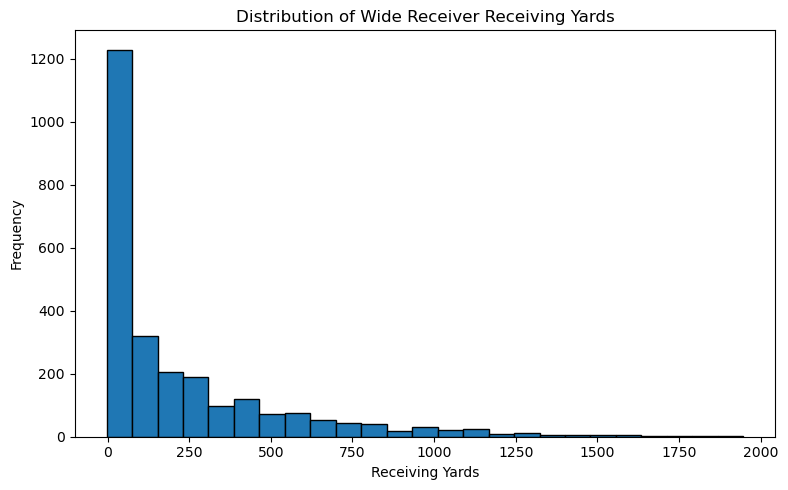

In [34]:
# Figure 1: Distribution of receiving yards

plt.figure(figsize=(8, 5))

plt.hist(
    eda_df["receiving_yards"].dropna(),
    bins=25,
    edgecolor="black"
)

plt.xlabel("Receiving Yards")
plt.ylabel("Frequency")
plt.title("Distribution of Wide Receiver Receiving Yards")

plt.tight_layout()
plt.show()

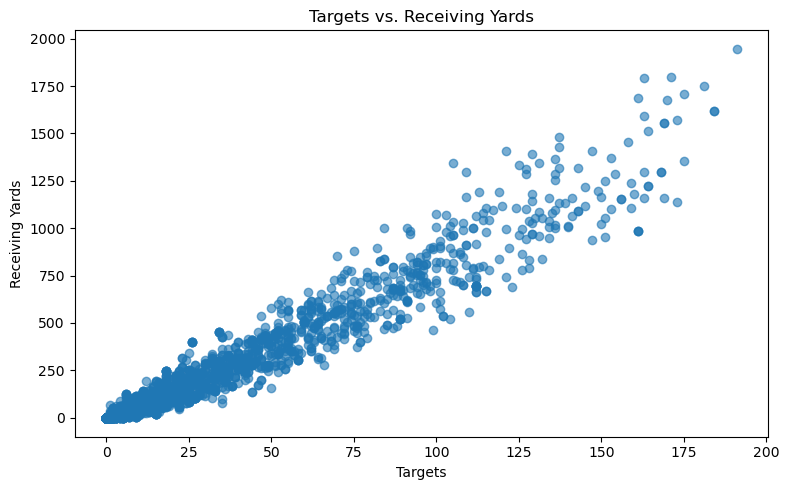

In [35]:
# Figure 2: Targets versus receiving yards

plt.figure(figsize=(8, 5))

plt.scatter(
    eda_df["targets"],
    eda_df["receiving_yards"],
    alpha=0.6
)

plt.xlabel("Targets")
plt.ylabel("Receiving Yards")
plt.title("Targets vs. Receiving Yards")

plt.tight_layout()
plt.show()

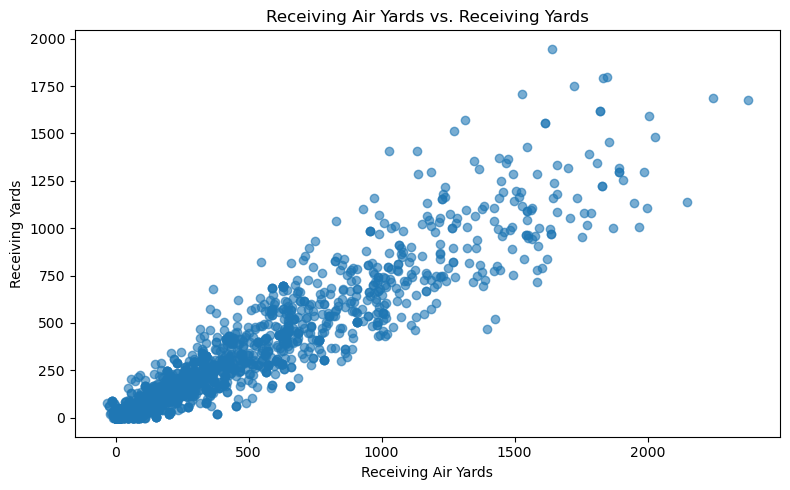

In [36]:
# Figure 3: Receiving air yards versus receiving yards

plt.figure(figsize=(8, 5))

plt.scatter(
    eda_df["receiving_air_yards"],
    eda_df["receiving_yards"],
    alpha=0.6
)

plt.xlabel("Receiving Air Yards")
plt.ylabel("Receiving Yards")
plt.title("Receiving Air Yards vs. Receiving Yards")

plt.tight_layout()
plt.show()

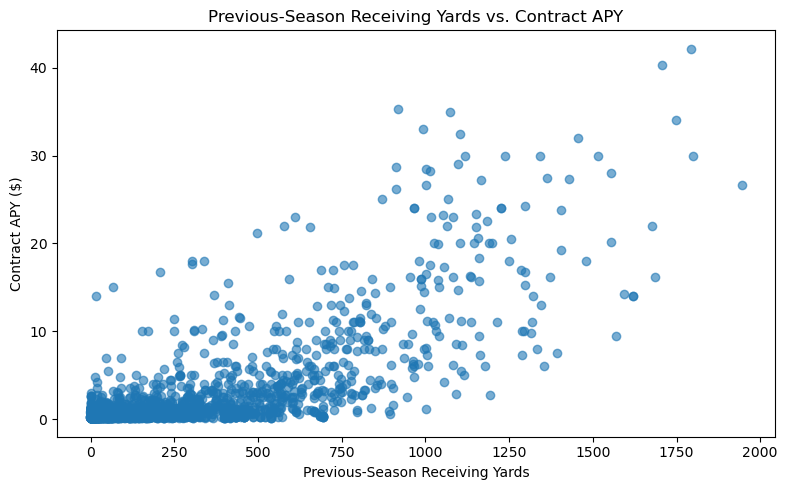

In [37]:
# Figure 4: Previous-season receiving yards versus contract APY

plt.figure(figsize=(8, 5))

plt.scatter(
    eda_df["receiving_yards"],
    eda_df["apy"],
    alpha=0.6
)

plt.xlabel("Previous-Season Receiving Yards")
plt.ylabel("Contract APY ($)")
plt.title("Previous-Season Receiving Yards vs. Contract APY")

plt.tight_layout()
plt.show()

In [38]:
# Variables selected for correlation analysis

correlation_variables = [
    "games",
    "receptions",
    "targets",
    "receiving_yards",
    "receiving_tds",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "receiving_first_downs",
    "receiving_epa",
    "target_share",
    "air_yards_share",
    "wopr",
    "apy"
]

correlation_variables = [
    col for col in correlation_variables
    if col in eda_df.columns
]

correlation_matrix = (
    eda_df[correlation_variables]
    .corr()
)

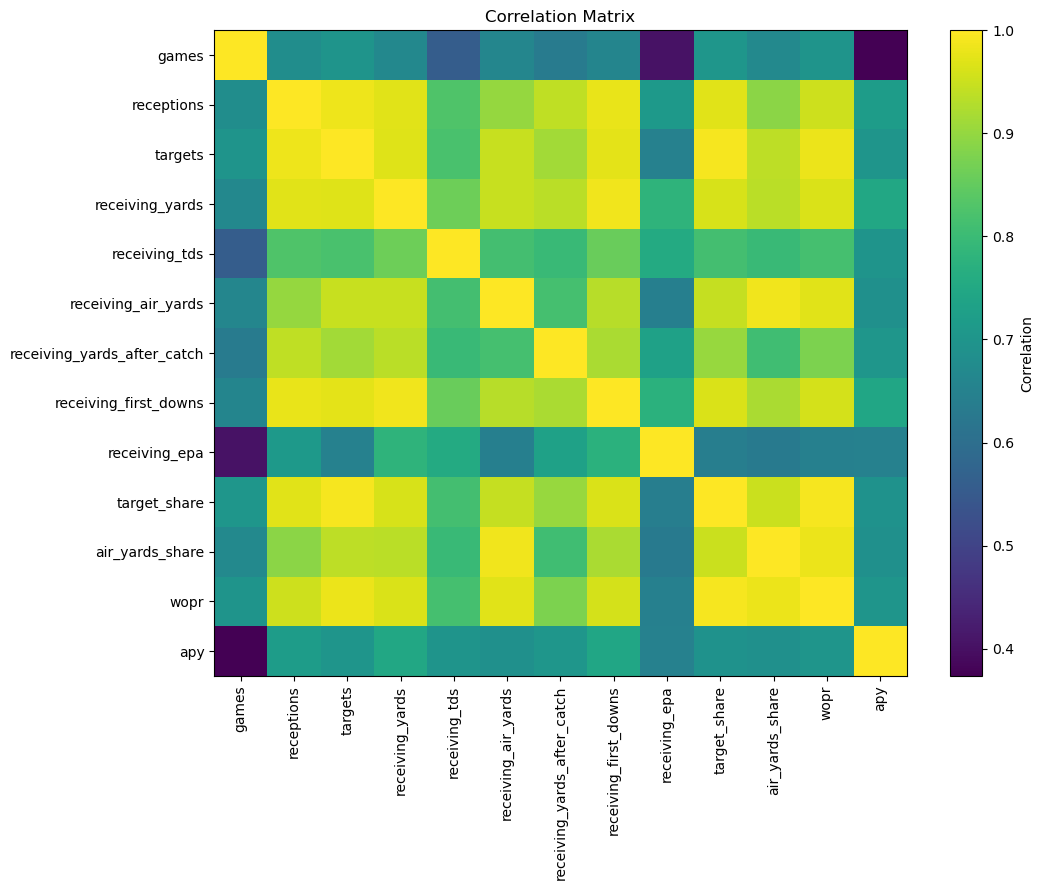

In [39]:
# Figure 5: Correlation matrix

plt.figure(figsize=(11, 9))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [40]:
# Correlations with the receiving_yards target variable

receiving_yards_correlations = (
    correlation_matrix["receiving_yards"]
    .drop("receiving_yards")
    .sort_values(ascending=False)
)

receiving_yards_correlations

receiving_first_downs          0.986222
receptions                     0.970901
targets                        0.970057
wopr                           0.964275
target_share                   0.963104
receiving_air_yards            0.946463
air_yards_share                0.936158
receiving_yards_after_catch    0.935265
receiving_tds                  0.861103
receiving_epa                  0.781655
apy                            0.748382
games                          0.665480
Name: receiving_yards, dtype: float64

In [41]:
# Identify highly correlated predictor pairs

high_correlations = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):

        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) >= 0.80:

            high_correlations.append([
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation
            ])

high_correlation_df = pd.DataFrame(
    high_correlations,
    columns=[
        "Variable 1",
        "Variable 2",
        "Correlation"
    ]
)

high_correlation_df["Correlation"] = (
    high_correlation_df["Correlation"].round(3)
)

high_correlation_df.sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

,Variable 1,Variable 2,Correlation
41,wopr,target_share,0.993
21,target_share,targets,0.990
16,receiving_first_downs,receiving_yards,0.986
30,air_yards_share,receiving_air_yards,0.986
0,targets,receptions,0.985
35,wopr,targets,0.982
42,wopr,air_yards_share,0.981
14,receiving_first_downs,receptions,0.978
15,receiving_first_downs,targets,0.974
20,target_share,receptions,0.973


In [42]:
# Define potential predictors and target

model_variables = [
    "games",
    "receptions",
    "targets",
    "receiving_tds",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "receiving_first_downs",
    "target_share",
    "air_yards_share",
    "wopr"
]

model_variables = [
    col for col in model_variables
    if col in eda_df.columns
]

model_df = (
    eda_df[
        model_variables + ["receiving_yards"]
    ]
    .dropna()
)

X = model_df[model_variables]

y = model_df["receiving_yards"]

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=6311
)

In [45]:
# Fit the initial linear regression model

receiving_yards_model = LinearRegression()

receiving_yards_model.fit(
    X_train,
    y_train
)

y_pred = receiving_yards_model.predict(X_test)

In [46]:
# Model performance

print(
    "R-squared:",
    round(r2_score(y_test, y_pred), 3)
)

print(
    "RMSE:",
    round(mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5, 2)
)

print(
    "MAE:",
    round(mean_absolute_error(
        y_test,
        y_pred
    ), 2)
)

R-squared: 0.991
RMSE: 27.26
MAE: 17.16


## Results

We were able to gain valuable insights from the exploratory process that raise some questions as well as further our knowledge into the topic.

To start off, we see that many of the variables are collinear, which is to be expected. Typically, if a player is doing well, you see it shown through many stats rather than just one and vice versa. We will have to make sure we have a proper set of working variables before we truly begin our modeling. Finding a set of relevant, but not too similar variables will be key.

Something interesting to note is that the distribution of previous season receiving yards is somewhat random compared to Contract APY which does confirm to us that there is a market for what we are attempting to develop. There isn't a really good science at the moment for offering the correct value of contract since we see a wide range of results from wide receivers at many different contract ranges. This is a great place to build off of.